# XGBoost

Import the required libraries

In [1]:
%%time

import sys

import numpy as np
import pandas as pd
import sklearn
import xgboost
from sklearn.metrics import accuracy_score, auc, classification_report, confusion_matrix, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBClassifier

__VERSIONS: list[str] = [
    f"python={sys.version.split()[0]}",
    f"numpy={np.__version__}",
    f"pandas={pd.__version__}",
    f"scikit-learn={sklearn.__version__}",
    f"xgboost={xgboost.__version__}",
]
__REQUIREMENTS_TXT: str = "\n".join(__VERSIONS)

del sklearn
del xgboost

print(__REQUIREMENTS_TXT, "\n")

python=3.10.12
numpy=2.2.6
pandas=2.3.2
scikit-learn=1.7.2
xgboost=3.1.0 

CPU times: user 3.7 s, sys: 506 ms, total: 4.2 s
Wall time: 1.98 s


In [2]:
import model_pipelines as mp

Define the variables

In [3]:
TARGET = "readmitted"
IDENTIFIERS = ["encounter_id", "patient_nbr"]

Skip the preprocessing (done in WS's notebook)

Skip transformation, but must explicitly cast categorical variables and use `enable_categorical=True`

In [4]:
data = pd.read_csv("preprocessed_data.csv")
for k in data.select_dtypes(include=["object"]):
    data[k] = data[k].astype("category")

In [5]:
data

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,time_in_hospital,num_lab_procedures,num_procedures,...,metformin,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,change,diabetesMed,readmitted
0,24437208,135,Caucasian,Female,[50-60),2,1,8,77,6,...,Steady,No,No,Change,No,No,Steady,Ch,Yes,1
1,29758806,378,Caucasian,Female,[50-60),3,1,2,49,1,...,No,No,No,No,No,No,No,No,No,0
2,189899286,729,Caucasian,Female,[80-90),1,3,4,68,2,...,Steady,No,No,No,No,No,No,No,Yes,0
3,64331490,774,Caucasian,Female,[80-90),1,1,3,46,0,...,Steady,No,No,Steady,No,No,No,Ch,Yes,0
4,14824206,927,AfricanAmerican,Female,[30-40),1,1,5,49,0,...,No,Steady,No,No,No,No,No,No,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70426,418513058,189351095,Caucasian,Female,[80-90),1,1,1,73,1,...,No,No,No,No,No,No,No,No,No,0
70427,359719064,189365864,Other,Male,[60-70),1,1,3,56,1,...,No,No,No,No,No,No,Steady,No,Yes,0
70428,338462954,189445127,Caucasian,Female,[80-90),1,1,3,39,0,...,Steady,No,Change,No,No,Steady,Change,Ch,Yes,0
70429,443811536,189481478,Caucasian,Female,[40-50),1,4,14,69,0,...,Change,No,No,Steady,No,No,Change,Ch,Yes,0


In [6]:
features = [col for col in data.columns if col not in IDENTIFIERS + [TARGET]]
X_train, X_test, y_train, y_test = mp.stratified_split(data, features=features, target=TARGET)

In [7]:
def get_pos_weight(y_train: pd.Series) -> float:
    vc = y_train.value_counts()
    return float(vc[0] / vc[1])

pos_weight = get_pos_weight(y_train)
print(f"{pos_weight = }")

pos_weight = 10.19205448354143


In [8]:
def make_xgb(**kwargs) -> XGBClassifier:
    return XGBClassifier(random_state=42, enable_categorical=True, **kwargs)

def make_balanced_xgb(pos_weight: float=pos_weight, **kwargs) -> XGBClassifier:
    return make_xgb(scale_pos_weight=pos_weight, **kwargs)

def train_xgb(
    xgb: XGBClassifier,
    features: list[str] | None=None,
    X_train_: pd.DataFrame | None=None,
    X_test_: pd.DataFrame | None=None,
    y_train_: pd.Series | None=None,
    y_test_: pd.Series | None=None
) -> None:
    if features is None:
        features = X_train.columns
    if X_train_ is None:
        X_train_ = X_train
    if X_test_ is None:
        X_test_ = X_test
    if y_train_ is None:
        y_train_ = y_train
    if y_test_ is None:
        y_test_ = y_test
    xgb.fit(X_train_[features], y_train_)
    
def eval_xgb(
    xgb: XGBClassifier,
    features: list[str] | None=None,
    X_train_: pd.DataFrame | None=None,
    X_test_: pd.DataFrame | None=None,
    y_train_: pd.Series | None=None,
    y_test_: pd.Series | None=None
) -> dict[str, np.ndarray]:
    if features is None:
        features = X_test.columns
    if X_train_ is None:
        X_train_ = X_train
    if X_test_ is None:
        X_test_ = X_test
    if y_train_ is None:
        y_train_ = y_train
    if y_test_ is None:
        y_test_ = y_test
    y_pred_train = xgb.predict(X_train_[features])
    y_proba_train = xgb.predict_proba(X_train_[features])
    y_pred = xgb.predict(X_test_[features])
    y_proba = xgb.predict_proba(X_test_[features])
    print(f"Accuracy (train): {accuracy_score(y_train, y_pred_train):.6f}")
    print(f"Accuracy (test): {accuracy_score(y_test, y_pred):.6f}")
    print(f"AUC ROC (train): {auc(*roc_curve(y_train, y_proba_train[:, 1])[:2]):.6f}")
    print(f"AUC ROC (test): {auc(*roc_curve(y_test, y_proba[:, 1])[:2]):.6f}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    return {
        "y_pred": y_pred,
        "y_proba": y_proba,
        "y_pred_train": y_pred_train,
        "y_proba_train": y_proba_train,
    }

# `eval_metric`: No difference between logloss, aucpr, and auc.

xgbs = {
    "unbalanced": make_xgb(),
    "balanced": make_balanced_xgb(),
    # "balanced_maxdepth10": make_balanced_xgb(max_depth=10),
    # "balanced_regalpha5": make_balanced_xgb(reg_alpha=5),
    # "balanced_reglambda5": make_balanced_xgb(reg_lambda=5),
    # "balanced_regboth10": make_balanced_xgb(reg_alpha=10, reg_lambda=10),
    # "overbalanced": make_xgb(scale_pos_weight=pos_weight / 1.5),
}

In [9]:
preds = {}
for k, xgb in xgbs.items():
    print(f"\033[36m{k}\033[0m")
    train_xgb(xgb)
    preds[k] = eval_xgb(xgb)

unbalanced
Accuracy (train): 0.927040
Accuracy (test): 0.908803
AUC ROC (train): 0.918537
AUC ROC (test): 0.606254
[[19150    92]
 [ 1835    53]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     19242
           1       0.37      0.03      0.05      1888

    accuracy                           0.91     21130
   macro avg       0.64      0.51      0.50     21130
weighted avg       0.86      0.91      0.87     21130

balanced
Accuracy (train): 0.842417
Accuracy (test): 0.750402
AUC ROC (train): 0.937169
AUC ROC (test): 0.591751
[[15239  4003]
 [ 1271   617]]
              precision    recall  f1-score   support

           0       0.92      0.79      0.85     19242
           1       0.13      0.33      0.19      1888

    accuracy                           0.75     21130
   macro avg       0.53      0.56      0.52     21130
weighted avg       0.85      0.75      0.79     21130



### XGBoost balanced

=== Train Set Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.84      0.91     44896
           1       0.35      0.88      0.50      4405

    accuracy                           0.84     49301
   macro avg       0.67      0.86      0.70     49301
weighted avg       0.93      0.84      0.87     49301

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.92      0.79      0.85     19242
           1       0.13      0.33      0.19      1888

    accuracy                           0.75     21130
   macro avg       0.53      0.56      0.52     21130
weighted avg       0.85      0.75      0.79     21130

=== Train Metrics ===
Accuracy: 0.8424, Precision: 0.9290, Recall: 0.8424, F1-score: 0.8701, ROC AUC: 0.9372
=== Test Metrics ===
Accuracy: 0.7504, Precision: 0.8525, Recall: 0.7504, F1-score: 0.7933, ROC AUC: 0.5918
=== Confusion Matrix ===


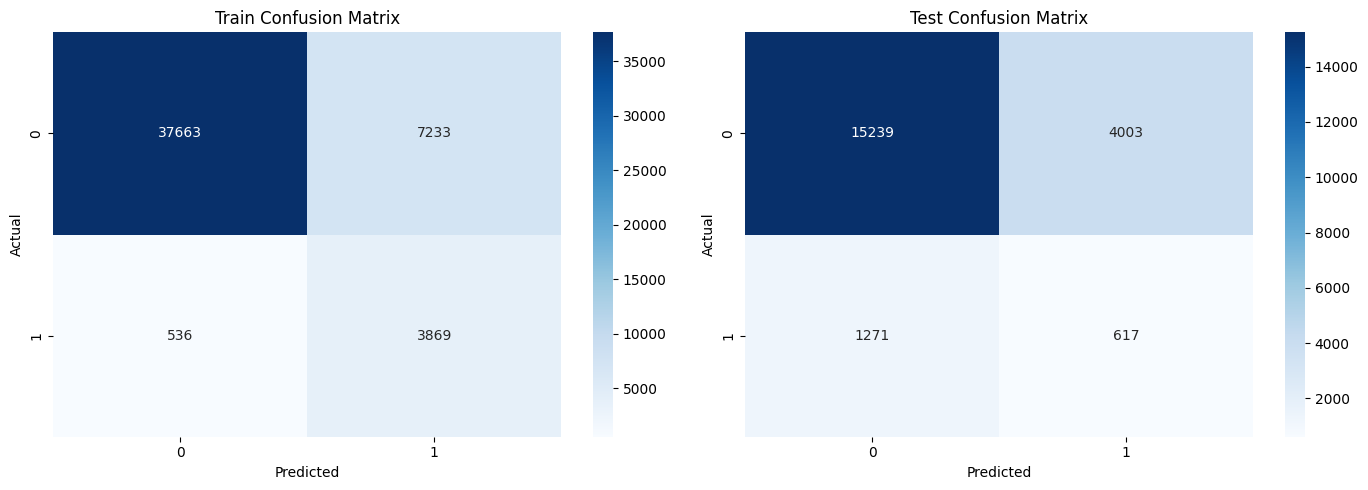

=== ROC AUC Curve ===


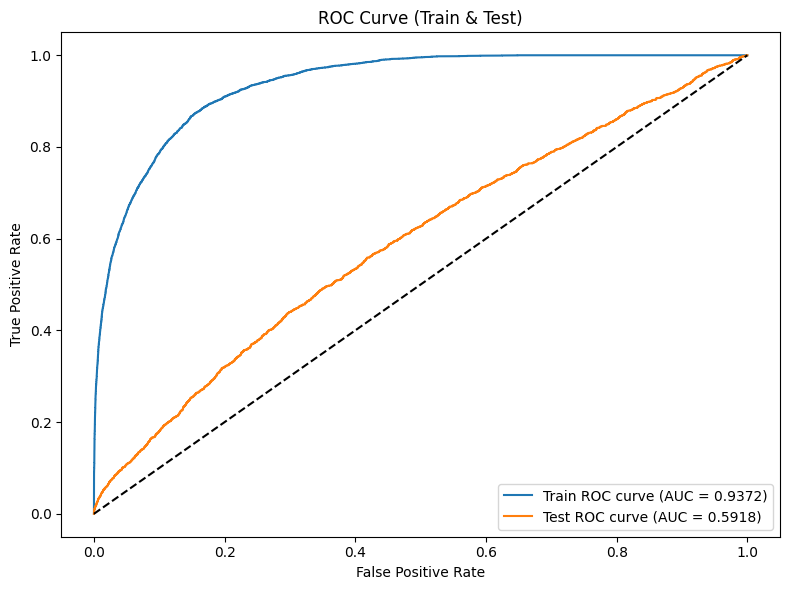

In [10]:
mp.evaluate_model(y_test, y_train=y_train, **preds["balanced"])

In [11]:
%%time

param_grid = {
    "n_estimators": [50, 100, 150],
    # "learning_rate": [0.2, 0.3, 0.4],
    "reg_alpha": [50, 100, 150],
    "reg_lambda": [50, 100, 150],
}

xgb_base = make_balanced_xgb()

grid_search = GridSearchCV(estimator=xgb_base, param_grid=param_grid, scoring="average_precision", cv=10, verbose=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Fitting 10 folds for each of 27 candidates, totalling 270 fits
[CV 5/10] END n_estimators=50, reg_alpha=50, reg_lambda=50;, score=0.161 total time=   3.2s
[CV 3/10] END n_estimators=50, reg_alpha=50, reg_lambda=50;, score=0.170 total time=   3.3s
[CV 7/10] END n_estimators=50, reg_alpha=50, reg_lambda=50;, score=0.149 total time=   3.2s
[CV 1/10] END n_estimators=50, reg_alpha=50, reg_lambda=50;, score=0.153 total time=   3.6s
[CV 2/10] END n_estimators=50, reg_alpha=50, reg_lambda=50;, score=0.156 total time=   3.5s
[CV 8/10] END n_estimators=50, reg_alpha=50, reg_lambda=50;, score=0.172 total time=   3.3s
[CV 4/10] END n_estimators=50, reg_alpha=50, reg_lambda=50;, score=0.167 total time=   3.6s
[CV 6/10] END n_estimators=50, reg_alpha=50, reg_lambda=50;, score=0.166 total time=   3.6s
[CV 9/10] END n_estimators=50, reg_alpha=50, reg_lambda=50;, score=0.170 total time=   3.1s
[CV 1/10] END n_estimators=50, reg_alpha=50, reg_lambda=100;, score=0.154 total time=   3.0s[CV 10/10] END n_

In [12]:
preds["cvbest"] = eval_xgb(best_xgb)

Accuracy (train): 0.668141
Accuracy (test): 0.644439
AUC ROC (train): 0.723053
AUC ROC (test): 0.646961
[[12587  6655]
 [  858  1030]]
              precision    recall  f1-score   support

           0       0.94      0.65      0.77     19242
           1       0.13      0.55      0.22      1888

    accuracy                           0.64     21130
   macro avg       0.54      0.60      0.49     21130
weighted avg       0.86      0.64      0.72     21130



In [13]:
def get_top_features(xgb: XGBClassifier, drop_scores: bool=True) -> list[str | tuple[str, float]]:
    top_features = sorted(xgb.get_booster().get_score(importance_type="gain").items(), key=lambda t: t[1], reverse=True)
    if drop_scores:
        top_features = [name for name, score in top_features]
    return top_features

get_top_features(best_xgb)

['discharge_disposition_id',
 'number_inpatient',
 'diabetesMed',
 'diag_1',
 'number_diagnoses',
 'number_emergency',
 'insulin',
 'age',
 'diag_2',
 'change',
 'time_in_hospital',
 'rosiglitazone',
 'metformin',
 'gender',
 'admission_type_id',
 'num_lab_procedures',
 'glipizide',
 'glimepiride',
 'number_outpatient',
 'num_medications',
 'max_glu_serum',
 'race',
 'num_procedures',
 'diag_3',
 'pioglitazone',
 'A1Cresult',
 'glyburide']

## (5-)Stepwise reduction from top 20 predictors

In [14]:
old_xgb = best_xgb
for n in [20, 15, 10, 5]:
    topn_features = get_top_features(old_xgb)[:n]
    print(f"Top {n}: {topn_features}")
    xgb = make_balanced_xgb(**grid_search.best_params_)
    train_xgb(xgb, features=topn_features)
    preds[n] = eval_xgb(xgb, features=topn_features)
    old_xgb = xgb
    print()

Top 20: ['discharge_disposition_id', 'number_inpatient', 'diabetesMed', 'diag_1', 'number_diagnoses', 'number_emergency', 'insulin', 'age', 'diag_2', 'change', 'time_in_hospital', 'rosiglitazone', 'metformin', 'gender', 'admission_type_id', 'num_lab_procedures', 'glipizide', 'glimepiride', 'number_outpatient', 'num_medications']
Accuracy (train): 0.654388
Accuracy (test): 0.633365
AUC ROC (train): 0.706538
AUC ROC (test): 0.644062
[[12319  6923]
 [  824  1064]]
              precision    recall  f1-score   support

           0       0.94      0.64      0.76     19242
           1       0.13      0.56      0.22      1888

    accuracy                           0.63     21130
   macro avg       0.54      0.60      0.49     21130
weighted avg       0.87      0.63      0.71     21130


Top 15: ['number_inpatient', 'discharge_disposition_id', 'diabetesMed', 'diag_1', 'age', 'time_in_hospital', 'insulin', 'number_emergency', 'number_diagnoses', 'diag_2', 'num_lab_procedures', 'metformin', '

### XGBoost, balanced, top 5 predictors, n_estimators = 50, alpha = 100, lambda = 100, AUC = 0.649

=== Train Set Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.67      0.78     44896
           1       0.14      0.56      0.23      4405

    accuracy                           0.66     49301
   macro avg       0.54      0.61      0.50     49301
weighted avg       0.87      0.66      0.73     49301

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.66      0.78     19242
           1       0.14      0.56      0.23      1888

    accuracy                           0.65     21130
   macro avg       0.54      0.61      0.50     21130
weighted avg       0.87      0.65      0.73     21130

=== Train Metrics ===
Accuracy: 0.6575, Precision: 0.8678, Recall: 0.6575, F1-score: 0.7306, ROC AUC: 0.6564
=== Test Metrics ===
Accuracy: 0.6549, Precision: 0.8682, Recall: 0.6549, F1-score: 0.7286, ROC AUC: 0.6490
=== Confusion Matrix ===


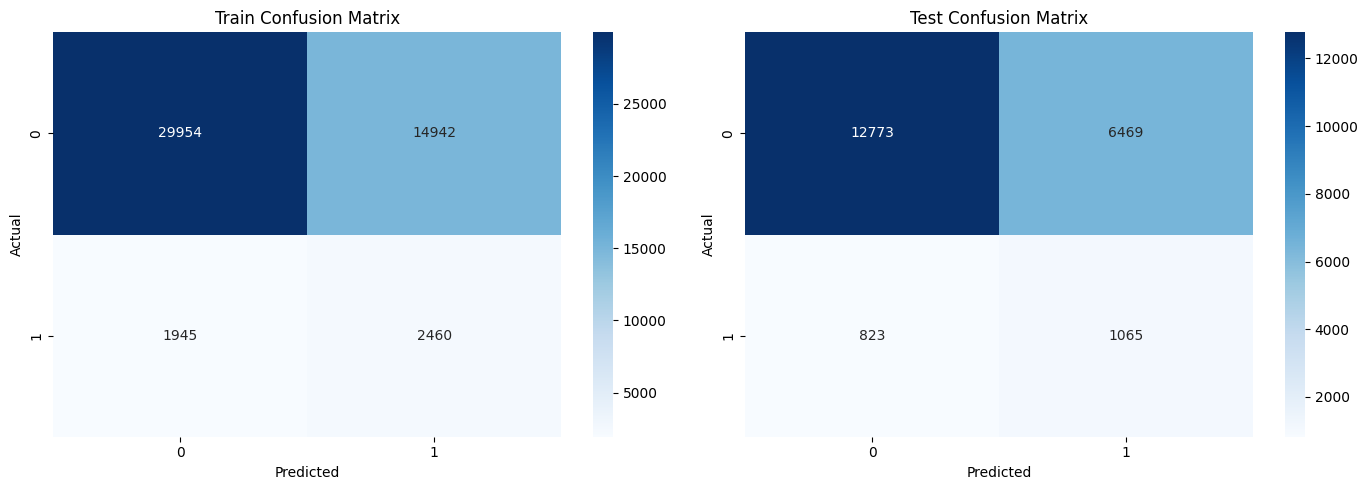

=== ROC AUC Curve ===


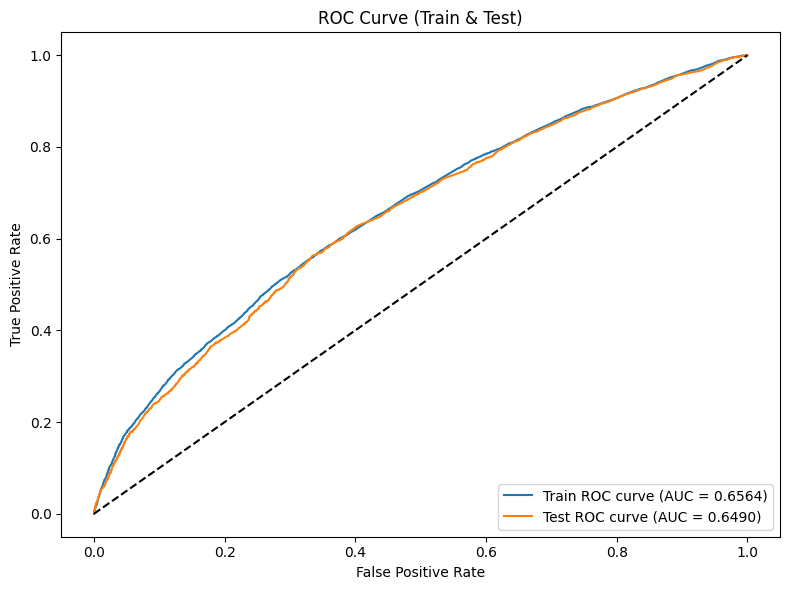

In [15]:
mp.evaluate_model(y_test, y_train=y_train, **preds[5])